# Gold Visualization

## Import libraries

In [1]:
import os
import sys
import pandas as pd
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from visualizer.visualizer import Visualizer
from model.arima_model import ArimaModel
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Initialize the Logger

In [2]:
my_logger = Logger(file_name=ARIMA_VISUALIZATION_LOG_FILE_BASE)

## Initialize the Visualizer

In [3]:
my_visualizer = Visualizer(logger=my_logger)

## Initialize the ArimaModel

In [4]:
arima_model = ArimaModel(logger=my_logger)

## Parameters

In [5]:
value_column_name = "#Passengers"

## Load data

In [6]:
df = pd.read_csv("AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


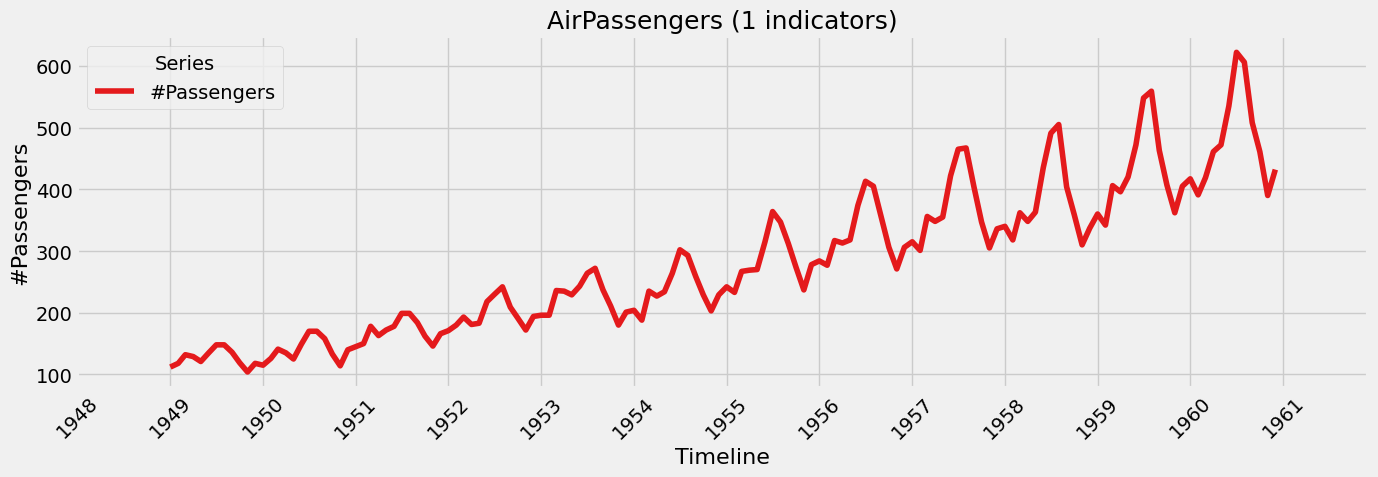

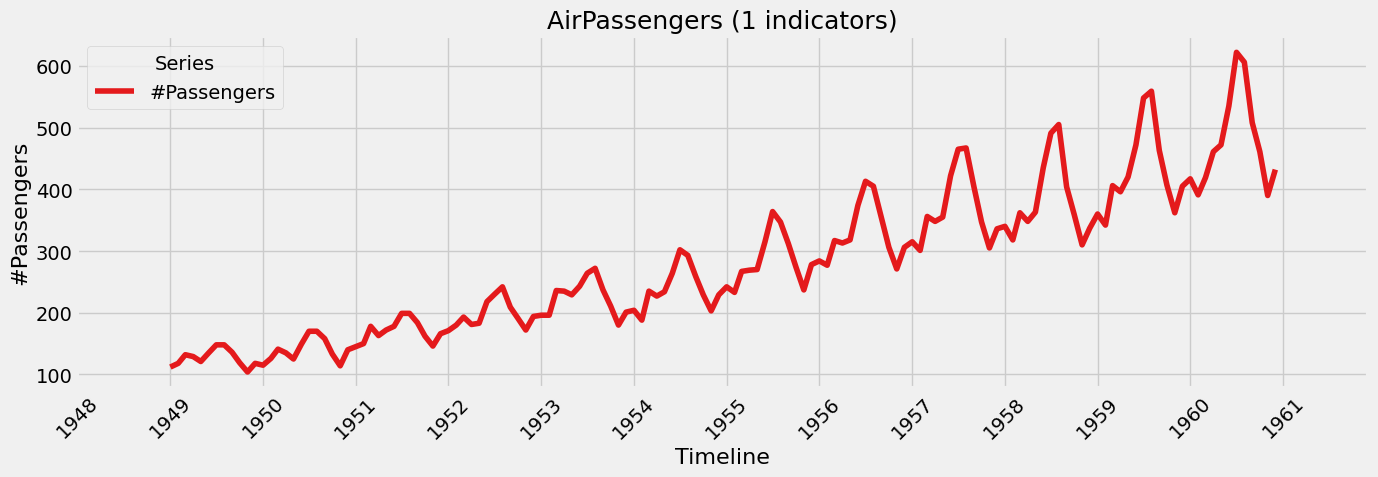

In [7]:
my_visualizer.plot_lines_chart(
    df,
    x_column="Month",
    y_columns=[value_column_name],
    title="AirPassengers",
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name="AirPassengers",
    marker=None,
)

## Divide data into train and test

In [8]:
train = df.iloc[: -int(len(df) * 0.2)]
test = df.iloc[-int(len(df) * 0.2) :]

In [9]:
train

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
111,1958-04-01,348
112,1958-05-01,363
113,1958-06-01,435
114,1958-07-01,491


In [10]:
test

,Month,#Passengers
116,1958-09-01,404
117,1958-10-01,359
118,1958-11-01,310
119,1958-12-01,337
120,1959-01-01,360
121,1959-02-01,342
122,1959-03-01,406
123,1959-04-01,396
124,1959-05-01,420
125,1959-06-01,472


## Fit the model

In [11]:
arima_model.fit(
    series=train[value_column_name], max_p=6, max_d=1, max_q=6, criterion="aic"
)

Searching ARIMA orders: 100%|██████████| 98/98 [00:45<00:00,  2.17it/s, best_order=(6, 1, 6), best_score=-270.02]
d:\DATA SCIENCE\GIT\master-thesis\src\model\arima_model.py:53: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, nlags, crit = kpss(
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
arima_model.get_order()

(6, 1, 6)

## Forecast

In [13]:
forecast = arima_model.forecast(steps=len(test))  # next 12 periods

In [14]:
forecast

116    470.759350
117    399.407916
118    348.558343
119    368.745789
120    383.292001
121    371.529856
122    383.065386
123    378.588704
124    379.465724
125    440.506810
126    480.485183
127    467.352530
128    461.934787
129    418.012564
130    368.377586
131    374.667958
132    375.785684
133    362.662671
134    384.345911
135    392.386662
136    391.432823
137    437.673170
138    462.892639
139    447.514379
140    452.362768
141    424.236720
142    378.826440
143    380.584462
Name: forecast, dtype: float64

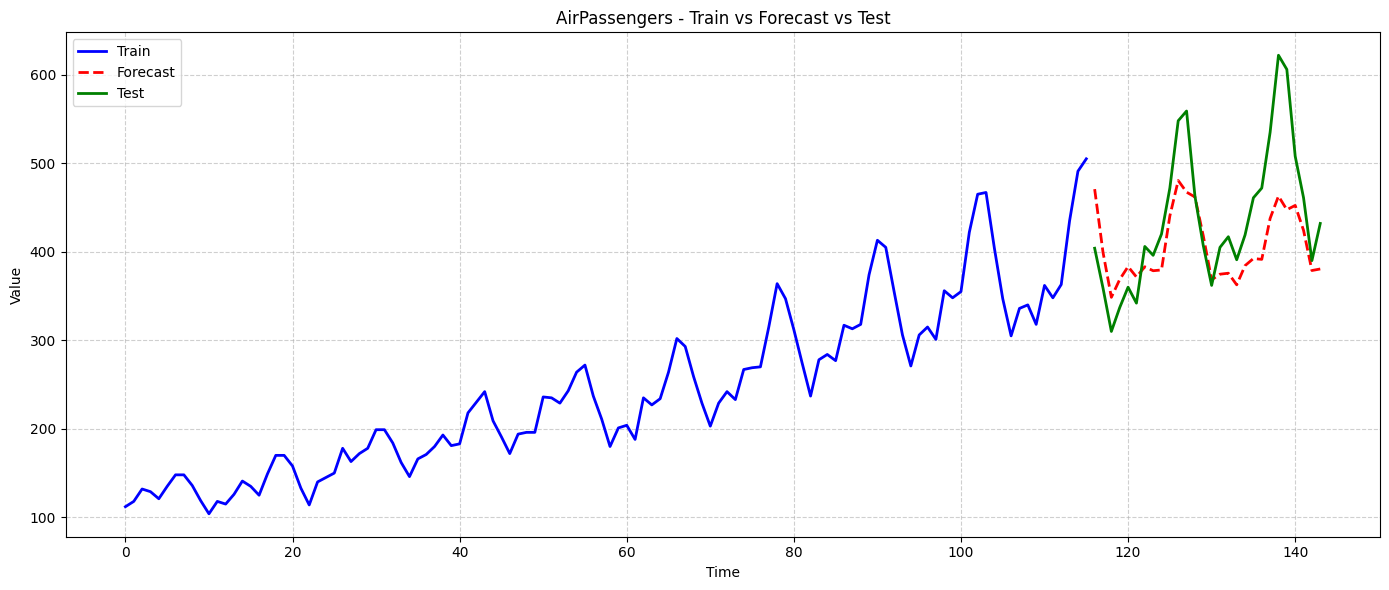

In [15]:
arima_model.plot_forecast(
    steps=len(test),
    test=test[value_column_name],
    title="AirPassengers - Train vs Forecast vs Test",
)